In [42]:
from bs4 import BeautifulSoup
# import pandas as pd
from datetime import datetime, timedelta
from itertools import combinations
import json
import requests
import math
from typing import Optional, List, Dict
import os

from pydantic import BaseModel
from typing import Mapping
import numpy as np
import polars as pl
import hvplot.polars
import pandas as pd
import altair as alt
import math

from shared.utils import formalize_data_with_str
from shared.random_rules import RandomRules

In [43]:
rr = RandomRules(
  TOTAL_NUMBERS = 50,
  CHOOSE = 6,
  MAX_PRIMES = 3,
  N_VALUES=["1", "2", "3"],
  # Rangos de valores de las bolillas
  MIN_B_VALUES = [1, 2, 3, 4, 5, 6],
  MAX_B_VALUES = [45, 46, 47, 48, 49, 50]
)

In [44]:
url = 'https://resultados.latinka.com.pe/i.do?m=historico&t=0&s=41'
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

tables = soup.select('table')
rows = tables[1].find_all('tr')

In [45]:
lst = []
post_str_b1 = None
post_str_b2 = None
post_str_b3 = None
post_str_b4 = None
post_str_b5 = None
post_str_blast = None
for row in rows:
  cols = [data.text.strip() for data in row.find_all('td')]
  
  id, bolillas_int, str_combo = formalize_data_with_str(bolillas_str=cols[2])
  cols.append(id)
  cols.append(bolillas_int)
  cols.extend([b for b in bolillas_int])
  cols.extend(str_combo)
  cols.append(post_str_b1)
  cols.append(post_str_b2)
  cols.append(post_str_b3)
  cols.append(post_str_b4)
  cols.append(post_str_b5)
  cols.append(post_str_blast)

  is_rare, reason = rr.is_rare_combination(bolillas_int, id)
  cols.append(is_rare)
  cols.append(reason)

  cols.append(rr.jumps_map(bolillas_int))
  cols.append(rr.unijump(bolillas_int))
  cols.append(rr.prime_counter(bolillas_int))
  cols.append(rr.evens_counter(bolillas_int))
  cols.append(rr.odds_counter(bolillas_int))

  jumps = rr.jumps(bolillas_int)
  cols.append(jumps[0])
  cols.append(jumps[1])
  cols.append(jumps[2])
  cols.append(jumps[3])
  cols.append(jumps[4])
  cols.append(sum(jumps))
  cols.append(sum([1 for j in jumps if j > 9]))
  
  lst.append(cols)

  post_str_b1 = str_combo[0]
  post_str_b2 = str_combo[1]
  post_str_b3 = str_combo[2]
  post_str_b4 = str_combo[3]
  post_str_b5 = str_combo[4]
  post_str_blast = str_combo[-1]

with open('./gn_tnk_v3.json', 'w') as file: 
  json.dump(lst, file)

dfRows = pl.DataFrame(
  lst,
  schema=[
    'fecha', 'sorteo', 'bolillas', 'yapa', 'adicionales', 'sorteo_extra',
    'id', 'combo', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6',
    'str_b1', 'str_b2', 'str_b3', 'str_b4', 'str_b5', 'str_b6',
    'post_str_b1', 'post_str_b2', 'post_str_b3', 'post_str_b4', 'post_str_b5', 'post_str_blast',
    'is_rare_combination', 'reason',
    "jumps_map", "unijump",
    "primes_count", "evens_count", "odds_count",
    "j1", "j2", "j3", "j4", "j5", "jsum", "joor"
  ],
  schema_overrides={
    'combo': pl.Array(pl.UInt8, 6),
    'b1': pl.UInt8,
    'b2': pl.UInt8,
    'b3': pl.UInt8,
    'b4': pl.UInt8,
    'b5': pl.UInt8,
    'b6': pl.UInt8,
    'reason': pl.UInt8,

    'primes_count': pl.String,
    'evens_count': pl.String,
    'odds_count': pl.String,
    "j1": pl.String,
    "j2": pl.String,
    "j3": pl.String,
    "j4": pl.String,
    "j5": pl.String,
    "jsum": pl.String,
    "joor": pl.String
  },
  orient='row'
)

TOTAL_LINES = len(dfRows)
print(f'{TOTAL_LINES=}')
display(dfRows.head(10))
dfRows.write_parquet('dfrows_tnk.parquet')

TOTAL_LINES=2495


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str
"""20/07/2025""","""1213""","""42 45 28 06 19 05""","""10""","""37""","""Promoción Sí o Sí""","""050619284245""","[5, 6, … 45]",5,6,19,28,42,45,"""05""","""06""","""19""","""28""","""42""","""45""",null,null,null,null,null,null,true,16,"""01_13_09_14_03""",-50,"""2""","""3""","""3""","""1""","""13""","""9""","""14""","""3""","""40""","""2"""
"""16/07/2025""","""1212""","""36 22 37 11 07 01""","""24""","""19""","""Promoción Sí o Sí""","""010711223637""","[1, 7, … 37]",1,7,11,22,36,37,"""01""","""07""","""11""","""22""","""36""","""37""","""05""","""06""","""19""","""28""","""42""","""45""",false,0,"""06_04_11_14_01""",1,"""3""","""2""","""4""","""6""","""4""","""11""","""14""","""1""","""36""","""2"""
"""13/07/2025""","""1211""","""09 32 43 49 38 24""","""05""","""35 30""","""Promoción Sí o Sí""","""092432384349""","[9, 24, … 49]",9,24,32,38,43,49,"""09""","""24""","""32""","""38""","""43""","""49""","""01""","""07""","""11""","""22""","""36""","""37""",true,16,"""15_08_06_05_06""",5,"""1""","""3""","""3""","""15""","""8""","""6""","""5""","""6""","""40""","""1"""
"""09/07/2025""","""1210""","""35 28 09 42 31 16""","""45""","""50 23""","""Promoción Sí o Sí""","""091628313542""","[9, 16, … 42]",9,16,28,31,35,42,"""09""","""16""","""28""","""31""","""35""","""42""","""09""","""24""","""32""","""38""","""43""","""49""",false,0,"""07_12_03_04_07""",-32,"""1""","""3""","""3""","""7""","""12""","""3""","""4""","""7""","""33""","""1"""
"""06/07/2025""","""1209""","""29 20 14 11 03 15""","""35""","""12 33 37""","""Promoción Sí o Sí""","""031114152029""","[3, 11, … 29]",3,11,14,15,20,29,"""03""","""11""","""14""","""15""","""20""","""29""","""09""","""16""","""28""","""31""","""35""","""42""",false,0,"""08_03_01_05_09""",-9,"""3""","""2""","""4""","""8""","""3""","""1""","""5""","""9""","""26""","""0"""
"""02/07/2025""","""1208""","""14 28 32 07 10 29""","""36""","""37 27 16""","""Promoción Sí o Sí""","""071014282932""","[7, 10, … 32]",7,10,14,28,29,32,"""07""","""10""","""14""","""28""","""29""","""32""","""03""","""11""","""14""","""15""","""20""","""29""",false,0,"""03_04_14_01_03""",70,"""2""","""4""","""2""","""3""","""4""","""14""","""1""","""3""","""25""","""1"""
"""29/06/2025""","""1207""","""47 37 32 22 24 23""","""04""","""20 39 09""","""Promoción Sí o Sí""","""222324323747""","[22, 23, … 47]",22,23,24,32,37,47,"""22""","""23""","""24""","""32""","""37""","""47""","""07""","""10""","""14""","""28""","""29""","""32""",true,24,"""01_01_08_05_10""",35,"""3""","""3""","""3""","""1""","""1""","""8""","""5""","""10""","""25""","""1"""
"""25/06/2025""","""1206""","""38 30 08 27 48 14""","""17""","""18""","""Promoción Sí o Sí""","""081427303848""","[8, 14, … 48]",8,14,27,30,38,48,"""08""","""14""","""27""","""30""","""38""","""48""","""22""","""23""","""24""","""32""","""37""","""47""",false,0,"""06_13_03_08_10""",-50,"""0""","""5""","""1""","""6""","""13""","""3""","""8""","""10""","""40""","""2"""
"""22/06/2025""","""1205""","""07 45 25 33 02 46""","""22""","""27 44""","""Promoción Sí o Sí""","""020725334546""","[2, 7, … 46]",2,7,25,33,45,46,"""02""","""07""","""25""","""33""","""45""","""46""","""08""","""14""","""27""","""30""","""38""","""48""",true,16,"""05_18_08_12_01""",-66,"""2""","""2""","""4""","""5""","""18""","""8""","""12""","""1""","""44""","""2"""


In [72]:

def count_column (col_name: str, k: int = None) -> None:
  df_viz = (dfRows if k == None else dfRows[0:k]) \
    .group_by(
      col_name
    ).agg(pl.count(col_name).alias('count')) \
    .sort("count", descending=True)

  chart = df_viz.hvplot.bar(
    x=col_name,
    y='count'
  )

  chart.opts(default_tools=["pan"])
  display(chart)
  return df_viz[col_name].to_list()

j1_count = count_column('j1', 100)
j2_count = count_column('j2', 100)
j3_count = count_column('j3', 100)
j4_count = count_column('j4', 100)
j5_count = count_column('j5', 100)

joor_count = count_column("joor", 100)
primes_count = count_column('primes_count', 100)
evens_count = count_column('evens_count', 100)
odds_count = count_column('odds_count', 100)

jsums = count_column('jsum', 100)
# print(jsums[0:22])



:Bars   [j1]   (count)

:Bars   [j2]   (count)

:Bars   [j3]   (count)

:Bars   [j4]   (count)

:Bars   [j5]   (count)

:Bars   [joor]   (count)

:Bars   [primes_count]   (count)

:Bars   [evens_count]   (count)

:Bars   [odds_count]   (count)

:Bars   [jsum]   (count)

In [47]:
dfRows.item(0, 'b2')

6

In [48]:
import holoviews as hv
def plot_post_col (col: str, post_col: str, test_value: str | None = None):
  if test_value == None:
    test_value = dfRows.item(0, col)
    print(f'Setting {test_value=}')

  df_viz = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .group_by(
      post_col
    ).agg(pl.count(post_col).alias('count')) \
    .sort("count", descending=True)
  
  
  df_10_last = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .head(10)
  
  # Agrega una columna que sea el porcentaje de la frecuencia relativa
  total = df_viz['count'].sum()
  df_viz = df_viz.with_columns(
    ( (pl.col('count') / total) * 100 ).alias('percent')
  )

  mean_percent = df_viz['percent'].mean()
  mean_percent_75 = mean_percent * 75 / 50
  mean_percent_25 = mean_percent * 25 / 50

  chart = df_viz.hvplot.bar(
    x=post_col,
    y='percent'
  )

  chart = chart * hv.HLine(mean_percent).opts(color='red')
  chart = chart * hv.HLine(mean_percent_75).opts(color='blue')
  chart = chart * hv.HLine(mean_percent_25).opts(color='blue')
  
  chart.opts(default_tools=["pan"])

  df_jumps_map = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .group_by(
      'jumps_map'
    ).agg(pl.count('jumps_map').alias('count')) \
    .sort("count", descending=True)
  
  df_unijump = dfRows \
    .filter(
      pl.col(col) == test_value,
      pl.col(post_col).is_not_null()
    ) \
    .group_by(
      'unijump'
    ).agg(pl.count('unijump').alias('count')) \
    .sort("count", descending=True)


  print(f'df_viz FOR {col} = {test_value}')
  display(df_viz)

  display(chart)
  

  print(f'df_10_last FOR {col} = {test_value}')
  last_results = list(set(df_10_last[post_col][0:3]))
  print(f'Last 3 results {last_results=}')
  display(df_10_last)
  
  print(f'df_jumps_map FOR {col} = {test_value}')
  display(df_jumps_map)
  # display(df_unijump)

  print(f'df_unijump FOR {col} = {test_value}')
  display(df_unijump)

  lst_post_str_b = df_viz.filter(pl.col('percent') >= mean_percent)[post_col].to_list()
  lst_jumps_map = df_jumps_map['jumps_map'].to_list() # Used to discard
  
  return lst_post_str_b, lst_jumps_map, last_results

In [49]:
possible_b1, exclude_jump_maps_b1, last_post_b1 = plot_post_col(col='str_b1', post_col='post_str_b1')

Setting test_value='05'
df_viz FOR str_b1 = 05


post_str_b1,count,percent
str,u32,f64
"""01""",22,10.328638
"""04""",21,9.859155
"""05""",20,9.389671
"""02""",19,8.920188
"""06""",17,7.981221
…,…,…
"""19""",1,0.469484
"""33""",1,0.469484
"""18""",1,0.469484


:Overlay
   .Bars.I    :Bars   [post_str_b1]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b1 = 05
Last 3 results last_results=['01', '04', '15']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str
"""08/06/2025""","""1201""","""05 08 25 18 34 12""","""14""","""44""","""Promoción Sí o Sí""","""050812182534""","[5, 8, … 34]",5,8,12,18,25,34,"""05""","""08""","""12""","""18""","""25""","""34""","""15""","""19""","""20""","""22""","""38""","""39""",false,0,"""03_04_06_07_09""",4,"""1""","""4""","""2""","""3""","""4""","""6""","""7""","""9""","""29""","""0"""
"""06/04/2025""","""1183""","""34 42 05 49 16 27""","""29""","""37""","""Promoción Sí o Sí""","""051627344249""","[5, 16, … 49]",5,16,27,34,42,49,"""05""","""16""","""27""","""34""","""42""","""49""","""01""","""12""","""24""","""35""","""39""","""49""",true,8,"""11_11_07_08_07""",-16,"""1""","""3""","""3""","""11""","""11""","""7""","""8""","""7""","""44""","""2"""
"""16/03/2025""","""1177""","""15 30 49 12 05 27""","""23""","""24""","""Promoción Sí o Sí""","""051215273049""","[5, 12, … 49]",5,12,15,27,30,49,"""05""","""12""","""15""","""27""","""30""","""49""","""04""","""32""","""34""","""37""","""41""","""42""",false,0,"""07_03_12_03_19""",74,"""1""","""2""","""4""","""7""","""3""","""12""","""3""","""19""","""44""","""2"""
"""23/02/2025""","""1171""","""10 44 30 05 08 36""","""25""","""47 02 23""","""Promoción Sí o Sí""","""050810303644""","[5, 8, … 44]",5,8,10,30,36,44,"""05""","""08""","""10""","""30""","""36""","""44""","""12""","""13""","""16""","""21""","""23""","""25""",true,16,"""03_02_20_06_08""",99,"""1""","""5""","""1""","""3""","""2""","""20""","""6""","""8""","""39""","""1"""
"""27/11/2024""","""1146""","""23 05 17 09 34 13""","""22""","""19 47""","""Promoción Sí o Sí""","""050913172334""","[5, 9, … 34]",5,9,13,17,23,34,"""05""","""09""","""13""","""17""","""23""","""34""","""09""","""12""","""15""","""27""","""35""","""42""",true,9,"""04_04_04_06_11""",-1,"""4""","""1""","""5""","""4""","""4""","""4""","""6""","""11""","""29""","""1"""
"""24/11/2024""","""1145""","""46 05 45 19 29 26""","""18""","""03 25""","""Promoción Sí o Sí""","""051926294546""","[5, 19, … 46]",5,19,26,29,45,46,"""05""","""19""","""26""","""29""","""45""","""46""","""05""","""09""","""13""","""17""","""23""","""34""",true,16,"""14_07_03_16_01""",-59,"""3""","""2""","""4""","""14""","""7""","""3""","""16""","""1""","""41""","""2"""
"""13/10/2024""","""1133""","""31 17 28 09 21 05""","""08""","""22 27""","""Promoción Sí o Sí""","""050917212831""","[5, 9, … 31]",5,9,17,21,28,31,"""05""","""09""","""17""","""21""","""28""","""31""","""08""","""10""","""12""","""29""","""31""","""47""",false,0,"""04_08_04_07_03""",-29,"""3""","""1""","""5""","""4""","""8""","""4""","""7""","""3""","""26""","""0"""
"""23/06/2024""","""1101""","""30 41 11 05 36 35""","""15""","""44 26""","""Promoción Sí o Sí""","""051130353641""","[5, 11, … 41]",5,11,30,35,36,41,"""05""","""11""","""30""","""35""","""36""","""41""","""01""","""06""","""09""","""11""","""14""","""43""",true,16,"""06_19_05_01_05""",-39,"""3""","""2""","""4""","""6""","""19""","""5""","""1""","""5""","""36""","""1"""
"""05/05/2024""","""1087""","""45 36 09 25 38 05""","""37""","""01 20 10""","""Promoción Sí o Sí""","""050925363845""","[5, 9, … 45]",5,9,25,36,38,45,"""05""","""09""","""25""","""36""","""38""","""45""","""01""","""04""","""20""","""27""","""45""","""47""",true,16,"""04_16_11_02_07""",5,"""1""","""2""","""4""","""4""","""16""","""11""","""2""","""7""","""40""","""2"""


df_jumps_map FOR str_b1 = 05


jumps_map,count
str,u32
"""08_07_02_06_06""",2
"""26_06_01_01_06""",1
"""01_03_13_01_13""",1
"""05_06_01_08_03""",1
"""13_01_04_06_10""",1
…,…
"""01_01_28_01_08""",1
"""05_01_02_10_14""",1
"""18_07_04_07_03""",1


df_unijump FOR str_b1 = 05


unijump,count
i64,u32
-36,6
-16,5
11,4
5,4
25,4
…,…
49,1
-12,1
28,1


In [50]:
possible_b2, exclude_jump_maps_b2, last_post_b2 = plot_post_col(col='str_b2', post_col='post_str_b2')

Setting test_value='06'
df_viz FOR str_b2 = 06


post_str_b2,count,percent
str,u32,f64
"""11""",9,8.333333
"""17""",8,7.407407
"""08""",8,7.407407
"""06""",7,6.481481
"""19""",7,6.481481
…,…,…
"""31""",1,0.925926
"""20""",1,0.925926
"""34""",1,0.925926


:Overlay
   .Bars.I    :Bars   [post_str_b2]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b2 = 06
Last 3 results last_results=['10', '16', '22']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str
"""30/04/2025""","""1190""","""11 36 33 06 02 16""","""37""","""14 07 10 01""","""Promoción Sí o Sí""","""020611163336""","[2, 6, … 36]",2,6,11,16,33,36,"""02""","""06""","""11""","""16""","""33""","""36""","""09""","""10""","""15""","""19""","""35""","""37""",true,8,"""04_05_05_17_03""",-51,"""2""","""4""","""2""","""4""","""5""","""5""","""17""","""3""","""34""","""1"""
"""20/04/2025""","""1187""","""33 02 06 42 34 11""","""37""","""49 20""","""Promoción Sí o Sí""","""020611333442""","[2, 6, … 42]",2,6,11,33,34,42,"""02""","""06""","""11""","""33""","""34""","""42""","""09""","""16""","""20""","""22""","""33""","""35""",false,0,"""04_05_22_01_08""",120,"""2""","""4""","""2""","""4""","""5""","""22""","""1""","""8""","""40""","""1"""
"""15/12/2024""","""1151""","""48 26 45 08 06 04""","""44""","""15 29""","""Promoción Sí o Sí""","""040608264548""","[4, 6, … 48]",4,6,8,26,45,48,"""04""","""06""","""08""","""26""","""45""","""48""","""19""","""22""","""28""","""33""","""35""","""47""",true,24,"""02_02_18_19_03""",29,"""0""","""5""","""1""","""2""","""2""","""18""","""19""","""3""","""44""","""2"""
"""06/10/2024""","""1131""","""14 09 02 25 08 06""","""44""","""05 19 15""","""Promoción Sí o Sí""","""020608091425""","[2, 6, … 25]",2,6,8,9,14,25,"""02""","""06""","""08""","""09""","""14""","""25""","""15""","""20""","""23""","""27""","""37""","""48""",true,16,"""04_02_01_05_11""",-7,"""1""","""4""","""2""","""4""","""2""","""1""","""5""","""11""","""23""","""1"""
"""28/08/2024""","""1120""","""11 37 46 47 06 03""","""29""","""14 09 05 40""","""Promoción Sí o Sí""","""030611374647""","[3, 6, … 47]",3,6,11,37,46,47,"""03""","""06""","""11""","""37""","""46""","""47""","""04""","""19""","""23""","""37""","""41""","""50""",true,17,"""03_05_26_09_01""",104,"""4""","""2""","""4""","""3""","""5""","""26""","""9""","""1""","""44""","""1"""
"""03/07/2024""","""1104""","""14 22 34 06 24 01""","""07""","""48 39 12""","""Promoción Sí o Sí""","""010614222434""","[1, 6, … 34]",1,6,14,22,24,34,"""01""","""06""","""14""","""22""","""24""","""34""","""07""","""09""","""19""","""20""","""22""","""34""",true,8,"""05_08_08_02_10""",23,"""0""","""5""","""1""","""5""","""8""","""8""","""2""","""10""","""33""","""1"""
"""26/06/2024""","""1102""","""43 06 14 01 09 11""","""30""","""17 42 45 20""","""Promoción Sí o Sí""","""010609111443""","[1, 6, … 43]",1,6,9,11,14,43,"""01""","""06""","""09""","""11""","""14""","""43""","""13""","""15""","""34""","""38""","""42""","""48""",true,16,"""05_03_02_03_29""",22,"""2""","""2""","""4""","""5""","""3""","""2""","""3""","""29""","""42""","""1"""
"""24/09/2023""","""1023""","""42 38 04 06 14 31""","""27""","""16 30""","""Promoción Sí o Sí""","""040614313842""","[4, 6, … 42]",4,6,14,31,38,42,"""04""","""06""","""14""","""31""","""38""","""42""","""06""","""19""","""23""","""44""","""45""","""47""",false,0,"""02_08_17_07_04""",48,"""1""","""5""","""1""","""2""","""8""","""17""","""7""","""4""","""38""","""1"""
"""21/12/2022""","""0944""","""05 18 25 12 06 33""","""14""","""27""","""Promoción Sí o Sí""","""050612182533""","[5, 6, … 33]",5,6,12,18,25,33,"""05""","""06""","""12""","""18""","""25""","""33""","""02""","""11""","""15""","""16""","""25""","""34""",true,8,"""01_06_06_07_08""",-7,"""1""","""3""","""3""","""1""","""6""","""6""","""7""","""8""","""28""","""0"""


df_jumps_map FOR str_b2 = 06


jumps_map,count
str,u32
"""02_04_04_03_15""",1
"""04_02_05_08_19""",1
"""02_11_17_01_08""",1
"""01_01_28_01_08""",1
"""01_05_02_08_21""",1
…,…
"""03_04_05_04_02""",1
"""01_26_06_03_04""",1
"""04_03_05_20_08""",1


df_unijump FOR str_b2 = 06


unijump,count
i64,u32
-20,3
-50,3
-9,3
34,3
-80,2
…,…
57,1
-41,1
-89,1


In [51]:
possible_b3, exclude_jump_maps_b3, last_post_b3 = plot_post_col(col='str_b3', post_col='post_str_b3')

Setting test_value='19'
df_viz FOR str_b3 = 19


post_str_b3,count,percent
str,u32,f64
"""18""",10,7.936508
"""11""",9,7.142857
"""14""",8,6.349206
"""21""",8,6.349206
"""20""",8,6.349206
…,…,…
"""27""",2,1.587302
"""04""",1,0.793651
"""36""",1,0.793651


:Overlay
   .Bars.I    :Bars   [post_str_b3]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b3 = 19
Last 3 results last_results=['21', '11']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str
"""07/07/2024""","""1105""","""07 22 34 20 19 09""","""32""","""17 02 35""","""Promoción Sí o Sí""","""070919202234""","[7, 9, … 34]",7,9,19,20,22,34,"""07""","""09""","""19""","""20""","""22""","""34""","""01""","""02""","""21""","""22""","""30""","""40""",false,0,"""02_10_01_02_12""",-28,"""2""","""3""","""3""","""2""","""10""","""1""","""2""","""12""","""27""","""2"""
"""16/06/2024""","""1099""","""08 46 19 02 23 21""","""28""","""42 27""","""Promoción Sí o Sí""","""020819212346""","[2, 8, … 46]",2,8,19,21,23,46,"""02""","""08""","""19""","""21""","""23""","""46""","""09""","""15""","""21""","""27""","""31""","""37""",true,8,"""06_11_02_02_23""",-11,"""3""","""3""","""3""","""6""","""11""","""2""","""2""","""23""","""44""","""2"""
"""17/03/2024""","""1073""","""17 19 13 41 34 24""","""26""","""18 22""","""Promoción Sí o Sí""","""131719243441""","[13, 17, … 41]",13,17,19,24,34,41,"""13""","""17""","""19""","""24""","""34""","""41""","""08""","""10""","""11""","""21""","""22""","""31""",true,1,"""04_02_05_10_07""",-7,"""4""","""2""","""4""","""4""","""2""","""5""","""10""","""7""","""28""","""1"""
"""11/02/2024""","""1063""","""19 41 01 31 27 12""","""44""","""35 05""","""Promoción Sí o Sí""","""011219273141""","[1, 12, … 41]",1,12,19,27,31,41,"""01""","""12""","""19""","""27""","""31""","""41""","""03""","""07""","""18""","""29""","""39""","""42""",false,0,"""11_07_08_04_10""",25,"""3""","""1""","""5""","""11""","""7""","""8""","""4""","""10""","""40""","""2"""
"""28/01/2024""","""1059""","""25 03 19 21 24 15""","""12""","""06""","""Promoción Sí o Sí""","""031519212425""","[3, 15, … 25]",3,15,19,21,24,25,"""03""","""15""","""19""","""21""","""24""","""25""","""04""","""13""","""21""","""22""","""34""","""48""",false,0,"""12_04_02_03_01""",-3,"""2""","""1""","""5""","""12""","""4""","""2""","""3""","""1""","""22""","""1"""
"""05/11/2023""","""1035""","""34 32 19 03 25 14""","""02""","""10 23 16 36""","""Promoción Sí o Sí""","""031419253234""","[3, 14, … 34]",3,14,19,25,32,34,"""03""","""14""","""19""","""25""","""32""","""34""","""02""","""08""","""11""","""19""","""35""","""41""",false,0,"""11_05_06_07_02""",1,"""2""","""3""","""3""","""11""","""5""","""6""","""7""","""2""","""31""","""1"""
"""16/08/2023""","""1012""","""37 19 13 26 45 02""","""32""","""25 33 38""","""Promoción Sí o Sí""","""021319263745""","[2, 13, … 45]",2,13,19,26,37,45,"""02""","""13""","""19""","""26""","""37""","""45""","""06""","""07""","""25""","""27""","""34""","""43""",true,1,"""11_06_07_11_08""",-7,"""4""","""2""","""4""","""11""","""6""","""7""","""11""","""8""","""43""","""2"""
"""25/06/2023""","""0997""","""19 26 23 25 02 11""","""03""","""37 14""","""Promoción Sí o Sí""","""021119232526""","[2, 11, … 26]",2,11,19,23,25,26,"""02""","""11""","""19""","""23""","""25""","""26""","""07""","""14""","""34""","""35""","""38""","""43""",true,1,"""09_08_04_02_01""",-6,"""4""","""2""","""4""","""9""","""8""","""4""","""2""","""1""","""24""","""0"""
"""19/04/2023""","""0978""","""39 32 42 01 19 18""","""17""","""05 45 14""","""Promoción Sí o Sí""","""011819323942""","[1, 18, … 42]",1,18,19,32,39,42,"""01""","""18""","""19""","""32""","""39""","""42""","""12""","""16""","""25""","""26""","""30""","""42""",false,0,"""17_01_13_07_03""",66,"""1""","""3""","""3""","""17""","""1""","""13""","""7""","""3""","""41""","""2"""


df_jumps_map FOR str_b3 = 19


jumps_map,count
str,u32
"""12_05_02_14_07""",1
"""05_07_11_10_01""",1
"""03_01_08_11_01""",1
"""08_06_04_11_03""",1
"""01_15_05_01_08""",1
…,…
"""12_03_01_06_07""",1
"""04_01_01_16_09""",1
"""09_07_09_04_07""",1


df_unijump FOR str_b3 = 19


unijump,count
i64,u32
-35,4
19,4
-31,3
-30,3
4,3
…,…
17,1
34,1
32,1


In [52]:
possible_b4, exclude_jump_maps_b4, last_post_b4 = plot_post_col(col='str_b4', post_col='post_str_b4')

Setting test_value='28'
df_viz FOR str_b4 = 28


post_str_b4,count,percent
str,u32,f64
"""24""",10,8.064516
"""33""",9,7.258065
"""29""",8,6.451613
"""25""",7,5.645161
"""27""",7,5.645161
…,…,…
"""35""",2,1.612903
"""32""",2,1.612903
"""41""",1,0.806452


:Overlay
   .Bars.I    :Bars   [post_str_b4]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b4 = 28
Last 3 results last_results=['38', '33', '15']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str
"""02/07/2025""","""1208""","""14 28 32 07 10 29""","""36""","""37 27 16""","""Promoción Sí o Sí""","""071014282932""","[7, 10, … 32]",7,10,14,28,29,32,"""07""","""10""","""14""","""28""","""29""","""32""","""03""","""11""","""14""","""15""","""20""","""29""",false,0,"""03_04_14_01_03""",70,"""2""","""4""","""2""","""3""","""4""","""14""","""1""","""3""","""25""","""1"""
"""18/06/2025""","""1204""","""26 45 28 09 24 50""","""14""","""07""","""Promoción Sí o Sí""","""092426284550""","[9, 24, … 50]",9,24,26,28,45,50,"""09""","""24""","""26""","""28""","""45""","""50""","""02""","""07""","""25""","""33""","""45""","""46""",true,24,"""15_02_02_17_05""",-44,"""0""","""4""","""2""","""15""","""2""","""2""","""17""","""5""","""41""","""2"""
"""05/03/2025""","""1174""","""01 32 03 12 28 47""","""20""","""49 06 23 24""","""Promoción Sí o Sí""","""010312283247""","[1, 3, … 47]",1,3,12,28,32,47,"""01""","""03""","""12""","""28""","""32""","""47""","""01""","""20""","""23""","""38""","""42""","""44""",false,0,"""02_09_16_04_15""",61,"""2""","""3""","""3""","""2""","""9""","""16""","""4""","""15""","""46""","""2"""
"""20/11/2024""","""1144""","""36 27 28 26 29 03""","""10""","""44 39 45""","""Promoción Sí o Sí""","""032627282936""","[3, 26, … 36]",3,26,27,28,29,36,"""03""","""26""","""27""","""28""","""29""","""36""","""05""","""19""","""26""","""29""","""45""","""46""",true,24,"""23_01_01_01_07""",28,"""2""","""3""","""3""","""23""","""1""","""1""","""1""","""7""","""33""","""1"""
"""23/10/2024""","""1136""","""28 09 16 01 46 40""","""50""","""37 41 27""","""Promoción Sí o Sí""","""010916284046""","[1, 9, … 46]",1,9,16,28,40,46,"""01""","""09""","""16""","""28""","""40""","""46""","""06""","""16""","""24""","""27""","""32""","""47""",true,24,"""08_07_12_12_06""",10,"""0""","""4""","""2""","""8""","""7""","""12""","""12""","""6""","""45""","""2"""
"""31/07/2024""","""1112""","""37 07 28 12 22 29""","""43""","""01 40 36 25""","""Promoción Sí o Sí""","""071222282937""","[7, 12, … 37]",7,12,22,28,29,37,"""07""","""12""","""22""","""28""","""29""","""37""","""02""","""17""","""36""","""38""","""41""","""43""",false,0,"""05_10_06_01_08""",5,"""3""","""3""","""3""","""5""","""10""","""6""","""1""","""8""","""30""","""1"""
"""24/07/2024""","""1110""","""23 32 28 19 38 25""","""40""","""03""","""Promoción Sí o Sí""","""192325283238""","[19, 23, … 38]",19,23,25,28,32,38,"""19""","""23""","""25""","""28""","""32""","""38""","""03""","""08""","""14""","""19""","""25""","""26""",false,0,"""04_02_03_04_06""",4,"""2""","""3""","""3""","""4""","""2""","""3""","""4""","""6""","""19""","""0"""
"""24/03/2024""","""1075""","""32 21 09 48 25 28""","""39""","""22""","""Promoción Sí o Sí""","""092125283248""","[9, 21, … 48]",9,21,25,28,32,48,"""09""","""21""","""25""","""28""","""32""","""48""","""06""","""11""","""16""","""19""","""23""","""30""",false,0,"""12_04_03_04_16""",14,"""0""","""3""","""3""","""12""","""4""","""3""","""4""","""16""","""39""","""2"""
"""03/01/2024""","""1052""","""35 28 12 15 04 39""","""29""","""""","""""","""041215283539""","[4, 12, … 39]",4,12,15,28,35,39,"""04""","""12""","""15""","""28""","""35""","""39""","""01""","""04""","""07""","""18""","""27""","""33""",false,0,"""08_03_13_07_04""",50,"""0""","""3""","""3""","""8""","""3""","""13""","""7""","""4""","""35""","""1"""


df_jumps_map FOR str_b4 = 28


jumps_map,count
str,u32
"""04_02_03_04_06""",1
"""04_11_10_06_10""",1
"""08_07_12_12_06""",1
"""02_09_15_02_09""",1
"""01_18_07_15_02""",1
…,…
"""08_03_06_01_04""",1
"""03_03_21_02_03""",1
"""03_04_01_04_04""",1


df_unijump FOR str_b4 = 28


unijump,count
i64,u32
20,4
4,4
1,3
-15,3
11,3
…,…
-63,1
-12,1
-74,1


In [53]:
possible_b5, exclude_jump_maps_b5, last_post_b5 = plot_post_col(col='str_b5', post_col='post_str_b5')

Setting test_value='42'
df_viz FOR str_b5 = 42


post_str_b5,count,percent
str,u32,f64
"""38""",8,8.421053
"""32""",6,6.315789
"""43""",6,6.315789
"""37""",6,6.315789
"""40""",5,5.263158
…,…,…
"""22""",2,2.105263
"""27""",2,2.105263
"""25""",2,2.105263


:Overlay
   .Bars.I    :Bars   [post_str_b5]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b5 = 42
Last 3 results last_results=['45', '39', '34']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str
"""15/06/2025""","""1203""","""41 24 42 34 29 44""","""26""","""08 30 39""","""Promoción Sí o Sí""","""242934414244""","[24, 29, … 44]",24,29,34,41,42,44,"""24""","""29""","""34""","""41""","""42""","""44""","""09""","""24""","""26""","""28""","""45""","""50""",true,8,"""05_05_07_01_02""",25,"""2""","""4""","""2""","""5""","""5""","""7""","""1""","""2""","""20""","""0"""
"""06/04/2025""","""1183""","""34 42 05 49 16 27""","""29""","""37""","""Promoción Sí o Sí""","""051627344249""","[5, 16, … 49]",5,16,27,34,42,49,"""05""","""16""","""27""","""34""","""42""","""49""","""01""","""12""","""24""","""35""","""39""","""49""",true,8,"""11_11_07_08_07""",-16,"""1""","""3""","""3""","""11""","""11""","""7""","""8""","""7""","""44""","""2"""
"""09/03/2025""","""1175""","""01 42 44 20 38 23""","""14""","""35 36 34 45 41""","""Promoción Sí o Sí""","""012023384244""","[1, 20, … 44]",1,20,23,38,42,44,"""01""","""20""","""23""","""38""","""42""","""44""","""07""","""16""","""17""","""32""","""34""","""44""",false,0,"""19_03_15_04_02""",83,"""1""","""4""","""2""","""19""","""3""","""15""","""4""","""2""","""43""","""2"""
"""17/11/2024""","""1143""","""11 37 07 46 42 15""","""23""","""24 01 08""","""Promoción Sí o Sí""","""071115374246""","[7, 11, … 46]",7,11,15,37,42,46,"""07""","""11""","""15""","""37""","""42""","""46""","""03""","""26""","""27""","""28""","""29""","""36""",true,8,"""04_04_22_05_04""",104,"""3""","""2""","""4""","""4""","""4""","""22""","""5""","""4""","""39""","""1"""
"""25/08/2024""","""1119""","""49 01 42 14 27 36""","""05""","""21 45""","""Promoción Sí o Sí""","""011427364249""","[1, 14, … 49]",1,14,27,36,42,49,"""01""","""14""","""27""","""36""","""42""","""49""","""03""","""06""","""11""","""37""","""46""","""47""",true,8,"""13_13_09_06_07""",-2,"""0""","""3""","""3""","""13""","""13""","""9""","""6""","""7""","""48""","""2"""
"""14/07/2024""","""1107""","""43 03 34 05 42 26""","""29""","""08 33""","""Promoción Sí o Sí""","""030526344243""","[3, 5, … 43]",3,5,26,34,42,43,"""03""","""05""","""26""","""34""","""42""","""43""","""01""","""19""","""38""","""40""","""43""","""47""",true,24,"""02_21_08_08_01""",-65,"""3""","""3""","""3""","""2""","""21""","""8""","""8""","""1""","""40""","""1"""
"""30/06/2024""","""1103""","""48 38 15 42 13 34""","""11""","""44 41 12 10""","""Promoción Sí o Sí""","""131534384248""","[13, 15, … 48]",13,15,34,38,42,48,"""13""","""15""","""34""","""38""","""42""","""48""","""01""","""06""","""14""","""22""","""24""","""34""",true,8,"""02_19_04_04_06""",-60,"""1""","""4""","""2""","""2""","""19""","""4""","""4""","""6""","""35""","""1"""
"""28/02/2024""","""1068""","""42 13 30 27 45 14""","""08""","""15 03""","""Promoción Sí o Sí""","""131427304245""","[13, 14, … 45]",13,14,27,30,42,45,"""13""","""14""","""27""","""30""","""42""","""45""","""06""","""25""","""27""","""31""","""33""","""48""",false,0,"""01_13_03_12_03""",-78,"""1""","""3""","""3""","""1""","""13""","""3""","""12""","""3""","""32""","""2"""
"""04/02/2024""","""1061""","""34 45 42 41 18 38""","""47""","""35 08 17 11 02""","""Promoción Sí o Sí""","""183438414245""","[18, 34, … 45]",18,34,38,41,42,45,"""18""","""34""","""38""","""41""","""42""","""45""","""08""","""12""","""16""","""27""","""30""","""48""",false,0,"""16_04_03_01_03""",17,"""1""","""4""","""2""","""16""","""4""","""3""","""1""","""3""","""27""","""1"""


df_jumps_map FOR str_b5 = 42


jumps_map,count
str,u32
"""07_05_24_04_03""",1
"""09_03_01_05_01""",1
"""02_14_18_06_03""",1
"""03_12_13_12_01""",1
"""01_04_11_06_01""",1
…,…
"""01_13_03_12_03""",1
"""07_03_07_16_02""",1
"""03_04_09_10_03""",1


df_unijump FOR str_b5 = 42


unijump,count
i64,u32
-29,4
-2,3
8,3
4,3
-16,2
…,…
-65,1
-36,1
-82,1


In [54]:
possible_blast, exclude_jump_maps_blast, last_post_blast = plot_post_col(col='str_b6', post_col='post_str_blast')

Setting test_value='45'
df_viz FOR str_b6 = 45


post_str_blast,count,percent
str,u32,f64
"""45""",46,15.384615
"""43""",36,12.040134
"""44""",29,9.698997
"""42""",28,9.364548
"""39""",21,7.023411
…,…,…
"""22""",1,0.334448
"""49""",1,0.334448
"""21""",1,0.334448


:Overlay
   .Bars.I    :Bars   [post_str_blast]   (percent)
   .HLine.I   :HLine   [x,y]
   .HLine.II  :HLine   [x,y]
   .HLine.III :HLine   [x,y]

df_10_last FOR str_b6 = 45
Last 3 results last_results=['47', '31', '49']


fecha,sorteo,bolillas,yapa,adicionales,sorteo_extra,id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_b2,post_str_b3,post_str_b4,post_str_b5,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor
str,str,str,str,str,str,str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str
"""21/05/2025""","""1196""","""07 36 24 34 45 11""","""01""","""33 47""","""Promoción Sí o Sí""","""071124343645""","[7, 11, … 45]",7,11,24,34,36,45,"""07""","""11""","""24""","""34""","""36""","""45""","""01""","""04""","""08""","""09""","""21""","""31""",false,0,"""04_13_10_02_09""",13,"""2""","""3""","""3""","""4""","""13""","""10""","""2""","""9""","""38""","""2"""
"""16/02/2025""","""1169""","""16 22 34 11 06 45""","""26""","""39 50""","""Promoción Sí o Sí""","""061116223445""","[6, 11, … 45]",6,11,16,22,34,45,"""06""","""11""","""16""","""22""","""34""","""45""","""02""","""19""","""29""","""31""","""44""","""47""",true,8,"""05_05_06_12_11""",-16,"""1""","""4""","""2""","""5""","""5""","""6""","""12""","""11""","""39""","""2"""
"""19/01/2025""","""1161""","""23 44 45 05 02 01""","""16""","""24 19""","""Promoción Sí o Sí""","""010205234445""","[1, 2, … 45]",1,2,5,23,44,45,"""01""","""02""","""05""","""23""","""44""","""45""","""06""","""10""","""21""","""31""","""32""","""49""",false,0,"""01_03_18_21_01""",14,"""3""","""2""","""4""","""1""","""3""","""18""","""21""","""1""","""44""","""2"""
"""08/12/2024""","""1149""","""44 08 45 43 26 17""","""29""","""37 15 36""","""Promoción Sí o Sí""","""081726434445""","[8, 17, … 45]",8,17,26,43,44,45,"""08""","""17""","""26""","""43""","""44""","""45""","""04""","""10""","""31""","""39""","""43""","""46""",true,8,"""09_09_17_01_01""",72,"""2""","""3""","""3""","""9""","""9""","""17""","""1""","""1""","""37""","""1"""
"""15/05/2024""","""1090""","""26 45 41 10 21 07""","""30""","""""","""""","""071021264145""","[7, 10, … 45]",7,10,21,26,41,45,"""07""","""10""","""21""","""26""","""41""","""45""","""13""","""15""","""18""","""21""","""38""","""44""",true,16,"""03_11_05_15_04""",-67,"""2""","""2""","""4""","""3""","""11""","""5""","""15""","""4""","""38""","""2"""
"""05/05/2024""","""1087""","""45 36 09 25 38 05""","""37""","""01 20 10""","""Promoción Sí o Sí""","""050925363845""","[5, 9, … 45]",5,9,25,36,38,45,"""05""","""09""","""25""","""36""","""38""","""45""","""01""","""04""","""20""","""27""","""45""","""47""",true,16,"""04_16_11_02_07""",5,"""1""","""2""","""4""","""4""","""16""","""11""","""2""","""7""","""40""","""2"""
"""28/02/2024""","""1068""","""42 13 30 27 45 14""","""08""","""15 03""","""Promoción Sí o Sí""","""131427304245""","[13, 14, … 45]",13,14,27,30,42,45,"""13""","""14""","""27""","""30""","""42""","""45""","""06""","""25""","""27""","""31""","""33""","""48""",false,0,"""01_13_03_12_03""",-78,"""1""","""3""","""3""","""1""","""13""","""3""","""12""","""3""","""32""","""2"""
"""25/02/2024""","""1067""","""45 40 31 35 14 05""","""33""","""43 23""","""Promoción Sí o Sí""","""051431354045""","[5, 14, … 45]",5,14,31,35,40,45,"""05""","""14""","""31""","""35""","""40""","""45""","""13""","""14""","""27""","""30""","""42""","""45""",true,24,"""09_17_04_05_05""",-50,"""2""","""2""","""4""","""9""","""17""","""4""","""5""","""5""","""40""","""1"""
"""04/02/2024""","""1061""","""34 45 42 41 18 38""","""47""","""35 08 17 11 02""","""Promoción Sí o Sí""","""183438414245""","[18, 34, … 45]",18,34,38,41,42,45,"""18""","""34""","""38""","""41""","""42""","""45""","""08""","""12""","""16""","""27""","""30""","""48""",false,0,"""16_04_03_01_03""",17,"""1""","""4""","""2""","""16""","""4""","""3""","""1""","""3""","""27""","""1"""


df_jumps_map FOR str_b6 = 45


jumps_map,count
str,u32
"""14_08_02_01_14""",1
"""03_05_04_08_01""",1
"""01_13_03_12_03""",1
"""10_02_01_01_11""",1
"""11_07_02_02_20""",1
…,…
"""26_06_01_01_06""",1
"""06_05_10_05_16""",1
"""12_05_06_13_06""",1


df_unijump FOR str_b6 = 45


unijump,count
i64,u32
4,6
-46,6
23,5
-9,5
29,5
…,…
-74,1
51,1
-43,1


In [55]:
b_count = rr.CHOOSE
min_b = rr.MIN_B_VALUES[0]
max_b = rr.MAX_B_VALUES[-1]


combos = combinations(range(min_b, max_b + 1), b_count)
# print("generating combos: ", len(list(combos)))

In [56]:
parquet_file = './parquet_tnk_v3.parquet'

# check if parquet_file exists
if not os.path.exists(parquet_file):
  print(f'{parquet_file=} does not exists. creating')
  lst = []
  post_str_b1 = None
  post_str_blast = None
  for row in combos:
    cols = []
    str_row = " ".join([str(r).zfill(2) for r in row])
    id, bolillas_int, str_combo = formalize_data_with_str(bolillas_str=str_row)
    cols.append(id)
    cols.append(bolillas_int)
    cols.extend([b for b in bolillas_int])
    cols.extend(str_combo)
    cols.append(post_str_b1)
    cols.append(post_str_blast)

    is_rare, reason = rr.is_rare_combination(bolillas_int, id)
    cols.append(is_rare)
    cols.append(reason)

    cols.append(rr.jumps_map(bolillas_int))
    cols.append(rr.unijump(bolillas_int))
    cols.append(rr.prime_counter(bolillas_int))
    cols.append(rr.evens_counter(bolillas_int))
    cols.append(rr.odds_counter(bolillas_int))

    jumps = rr.jumps(bolillas_int)
    cols.append(jumps[0])
    cols.append(jumps[1])
    cols.append(jumps[2])
    cols.append(jumps[3])
    cols.append(jumps[4])
    cols.append(sum(jumps))
    cols.append(sum([1 for j in jumps if j > 9]))
    
    lst.append(cols)

    post_str_b1 = str_combo[0]
    post_str_blast = str_combo[-1]

  df_Orows = pl.DataFrame(
    lst,
    schema=[
      # 'fecha', 'sorteo', 'bolillas',
      'id', 'combo', 'b1', 'b2', 'b3', 'b4', 'b5', 'b6',
      'str_b1', 'str_b2', 'str_b3', 'str_b4', 'str_b5', 'str_b6',
      'post_str_b1', 'post_str_blast',
      'is_rare_combination', 'reason',
      "jumps_map", "unijump",
      "primes_count", "evens_count", "odds_count",
      "j1", "j2", "j3", "j4", "j5", "jsum"
    ],
    schema_overrides={
      'combo': pl.Array(pl.UInt8, 6),
      'b1': pl.UInt8,
      'b2': pl.UInt8,
      'b3': pl.UInt8,
      'b4': pl.UInt8,
      'b5': pl.UInt8,
      'b6': pl.UInt8,
      'reason': pl.UInt8,

      'primes_count': pl.String,
      'evens_count': pl.String,
      'odds_count': pl.String,
      "j1": pl.String,
      "j2": pl.String,
      "j3": pl.String,
      "j4": pl.String,
      "j5": pl.String,
      "jsum": pl.String,
      "joor": pl.String
    },
    orient='row'
  )

  df_Orows.write_parquet(parquet_file)
  TOTAL_LINES = len(df_Orows)
  print(f'{TOTAL_LINES=} loaded to {parquet_file=}')

  display(df_Orows.head(10))
else:
  df_Orows = pl.read_parquet(parquet_file)

In [77]:
# possible_b1, exclude_jump_maps_b1
df_possible = df_Orows.filter(
  # pl.col("str_b1").is_in(["10", "11", "12", "13", "14", "15", "16"]),
  pl.col("str_b1").is_in(["02", "04", "06"]),
  # pl.col("str_b1").is_in(possible_b1),
  # pl.col("str_b2").is_in(possible_b2),
  # pl.col("str_b3").is_in(possible_b3),
  # pl.col("str_b4").is_in(possible_b4),
  # pl.col("str_b5").is_in(possible_b5),
  # pl.col("str_b6").is_in(possible_blast),
  
  # ~pl.col("str_b1").is_in(last_post_b1),
  # ~pl.col("str_b2").is_in(last_post_b2 + ["40", "41", "42", "43", "44", "45", "46", "47", "48", "49"]),
  # ~pl.col("str_b3").is_in(last_post_b3 + ["40", "41", "42", "43", "44", "45", "46", "47", "48", "49"]),
  # ~pl.col("str_b4").is_in(last_post_b4 + ["10", "11", "12", "13", "14", "15", "16", "17", "18", "19", "20", "21", "22", "23", "24", "25"]),
  # ~pl.col("str_b5").is_in(last_post_b5 + ["27"]),
  # ~pl.col("str_b6").is_in(last_post_blast + ["20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34", "45", "46", "47", "48", "49", "50"]),

  # ~pl.col("str_b1").is_in(last_post_b1),
  # ~pl.col("str_b2").is_in(last_post_b2 + ["02", "03", "04"]),
  # ~pl.col("str_b3").is_in(last_post_b3 + ["03"]),
  # ~pl.col("str_b5").is_in(last_post_b5),
  # ~pl.col("str_b6").is_in(last_post_blast + ["20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34"]),


  ~pl.col("str_b1").is_in(last_post_b1 + ["05", "06", "19", "28", "42", "45"]),
  ~pl.col("str_b2").is_in(last_post_b2 + ["05", "06", "19", "28", "42", "45"]),
  ~pl.col("str_b3").is_in(last_post_b3 + ["05", "06", "19", "28", "42", "45"]),
  ~pl.col("str_b4").is_in(last_post_b4 + ["05", "06", "19", "28", "42", "45"]),
  ~pl.col("str_b5").is_in(last_post_b5 + ["05", "06", "19", "28", "42", "45"]),
  ~pl.col("str_b6").is_in(last_post_blast + ["05", "06", "19", "28", "42", "45"] + last_post_blast + ["20", "21", "22", "23", "24", "25", "26", "27", "28", "29", "30", "31", "32", "33", "34"]),

  ~pl.col("jumps_map").is_in(exclude_jump_maps_b1 + exclude_jump_maps_b2 + exclude_jump_maps_b3 + exclude_jump_maps_b4 + exclude_jump_maps_b5 + exclude_jump_maps_blast),
  # pl.col("is_rare_combination") == False
  pl.col("j1").is_in(j1_count[0:11]),
  pl.col("j2").is_in(j2_count[0:9]),
  pl.col("j3").is_in(j3_count[0:12]),
  pl.col("j4").is_in(j4_count[0:10]),
  pl.col("j5").is_in(j5_count[0:9]),
  # pl.col("joor").is_in(["0", "1", "2"]),
  pl.col("joor").is_in(["1", "2"]),

  pl.col("primes_count").is_in(["2", "1", "0", "3"]),
  pl.col("evens_count").is_in(["3", "2", "4"]),
  pl.col("odds_count").is_in(["3", "4", "2"]),

  pl.col("jsum").is_in(jsums[0:16])

)


display(df_possible)

id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor
str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str
"""020304082435""","[2, 3, … 35]",2,3,4,8,24,35,"""02""","""03""","""04""","""08""","""24""","""35""","""02""","""34""",true,24,"""01_01_04_16_11""",-32,"""2""","""4""","""2""","""1""","""1""","""4""","""16""","""11""","""33""","""2"""
"""020304092535""","[2, 3, … 35]",2,3,4,9,25,35,"""02""","""03""","""04""","""09""","""25""","""35""","""02""","""34""",true,24,"""01_01_05_16_10""",-27,"""2""","""2""","""4""","""1""","""1""","""5""","""16""","""10""","""33""","""2"""
"""020304102635""","[2, 3, … 35]",2,3,4,10,26,35,"""02""","""03""","""04""","""10""","""26""","""35""","""02""","""34""",true,8,"""01_01_06_16_09""",-22,"""2""","""4""","""2""","""1""","""1""","""6""","""16""","""9""","""33""","""1"""
"""020304102637""","[2, 3, … 37]",2,3,4,10,26,37,"""02""","""03""","""04""","""10""","""26""","""37""","""02""","""36""",true,8,"""01_01_06_16_11""",-20,"""3""","""4""","""2""","""1""","""1""","""6""","""16""","""11""","""35""","""2"""
"""020304112738""","[2, 3, … 38]",2,3,4,11,27,38,"""02""","""03""","""04""","""11""","""27""","""38""","""02""","""37""",true,8,"""01_01_07_16_11""",-14,"""3""","""3""","""3""","""1""","""1""","""7""","""16""","""11""","""36""","""2"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""021730394446""","[2, 17, … 46]",2,17,30,39,44,46,"""02""","""17""","""30""","""39""","""44""","""46""","""02""","""45""",false,0,"""15_13_09_05_02""",-1,"""2""","""4""","""2""","""15""","""13""","""9""","""5""","""2""","""44""","""2"""
"""021730394450""","[2, 17, … 50]",2,17,30,39,44,50,"""02""","""17""","""30""","""39""","""44""","""50""","""02""","""49""",false,0,"""15_13_09_05_06""",3,"""2""","""4""","""2""","""15""","""13""","""9""","""5""","""6""","""48""","""2"""
"""021730394748""","[2, 17, … 48]",2,17,30,39,47,48,"""02""","""17""","""30""","""39""","""47""","""48""","""02""","""50""",false,0,"""15_13_09_08_01""",-14,"""3""","""3""","""3""","""15""","""13""","""9""","""8""","""1""","""46""","""2"""


In [94]:
df_possible.sample(n=1)


id,combo,b1,b2,b3,b4,b5,b6,str_b1,str_b2,str_b3,str_b4,str_b5,str_b6,post_str_b1,post_str_blast,is_rare_combination,reason,jumps_map,unijump,primes_count,evens_count,odds_count,j1,j2,j3,j4,j5,jsum,joor
str,"array[u8, 6]",u8,u8,u8,u8,u8,u8,str,str,str,str,str,str,str,str,bool,u8,str,i64,str,str,str,str,str,str,str,str,str,str
"""021725394346""","[2, 17, … 46]",2,17,25,39,43,46,"""02""","""17""","""25""","""39""","""43""","""46""","""02""","""45""",false,0,"""15_08_14_04_03""",54,"""3""","""2""","""4""","""15""","""8""","""14""","""4""","""3""","""44""","""2"""


# Aplicando Laplace + dist teórica

In [59]:
import numpy as np
from collections import defaultdict
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parámetros por casilla
PARAMETROS_CASILLA = {
    "b1": {"rango": (1, 45), "mu": 5, "sigma": 5},
    "b2": {"rango": (2, 46), "mu": 13.5, "sigma": 5},
    "b3": {"rango": (3, 47), "mu": 21, "sigma": 4},
    "b4": {"rango": (4, 48), "mu": 28, "sigma": 4},
    "b5": {"rango": (5, 49), "mu": 35.5, "sigma": 5},
    "b6": {"rango": (6, 50), "mu": 45, "sigma": 5},
}

def calcular_probabilidades_hibridas(casilla, valores, suavizado=1, mezcla=0.5, top_n=5, graficar=False):
    # Obtener parámetros
    param = PARAMETROS_CASILLA[casilla]
    r_min, r_max = param["rango"]
    mu = param["mu"]
    sigma = param["sigma"]
    
    rango = list(range(r_min, r_max + 1))
    total_posibles = len(rango)
    total_observaciones = len(valores)

    # --- Probabilidad teórica (distribución normal)
    dist_normal = norm(loc=mu, scale=sigma)
    p_teorica = {v: dist_normal.pdf(v) for v in rango}

    # Normalizar las probabilidades teóricas
    suma_teorica = sum(p_teorica.values())
    for v in p_teorica:
        p_teorica[v] /= suma_teorica

    # --- Probabilidad empírica con Laplace
    conteo = defaultdict(int)
    for v in valores:
        conteo[v] += 1

    p_laplace = {
        v: (conteo[v] + suavizado) / (total_observaciones + total_posibles * suavizado)
        for v in rango
    }

    # --- Mezcla de ambos modelos
    p_combinada = {
        v: mezcla * p_teorica[v] + (1 - mezcla) * p_laplace[v]
        for v in rango
    }

    # Ordenar resultados
    p_ordenada = dict(sorted(p_combinada.items(), key=lambda x: x[1], reverse=True))

    # Graficar si se desea
    if graficar:
        plt.figure(figsize=(10, 4))
        plt.plot(list(p_teorica.keys()), list(p_teorica.values()), label='Distribución Teórica', linestyle='--', alpha=0.7)
        plt.plot(list(p_laplace.keys()), list(p_laplace.values()), label='Laplace (Empírica)', linestyle=':', alpha=0.7)
        plt.plot(list(p_combinada.keys()), list(p_combinada.values()), label='Combinada', linewidth=2)
        plt.title(f"Probabilidades combinadas para {casilla}")
        plt.xlabel("Valor")
        plt.ylabel("Probabilidad")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # Retornar los valores más probables
    return list(p_ordenada.items())[:top_n]


In [60]:
def next_gen_analyze (col_analyze: str, top_n: int = 10, body_size: int = 104):
  values_explore = dfRows[col_analyze].to_list()[0:body_size]
  values_explore.reverse()

  # valores más probables usando mezcla 50% teórica y 50% datos
  top_valores = calcular_probabilidades_hibridas(col_analyze, values_explore, mezcla=0.5, graficar=True, top_n=top_n)

  print(f"🎯 Siguientes valores más probables para {col_analyze}:")
  result = []
  for val, prob in top_valores:
    print(f"  {val}: {prob:.4f}")
    result.append(val)
  
  return result


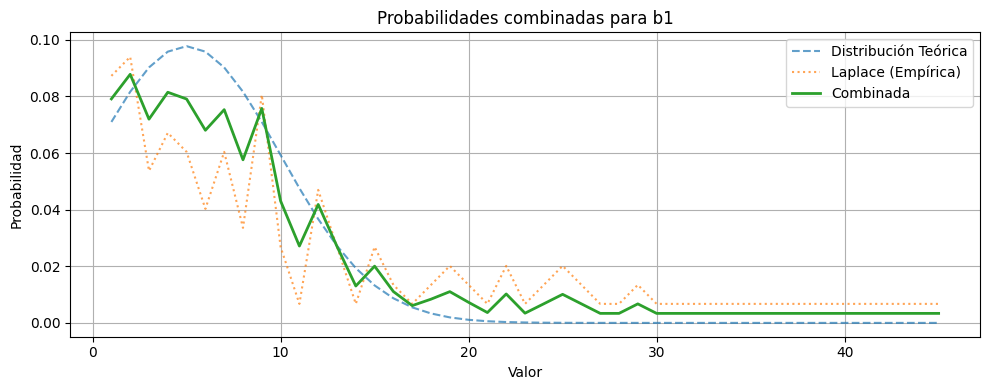

🎯 Siguientes valores más probables para b1:
  2: 0.0878
  4: 0.0815
  1: 0.0791
  5: 0.0791
  9: 0.0758
  7: 0.0753
  3: 0.0720
  6: 0.0680
  8: 0.0576
  10: 0.0431


In [61]:
b1_vals = next_gen_analyze("b1", body_size=104)

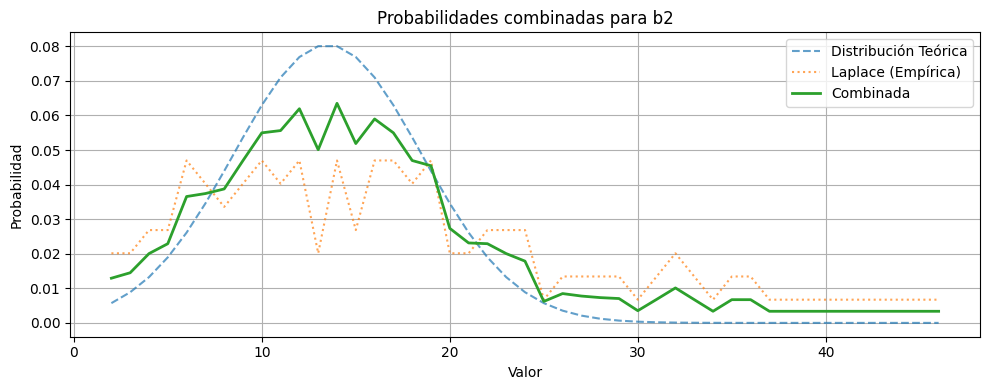

🎯 Siguientes valores más probables para b2:
  14: 0.0635
  12: 0.0619
  16: 0.0590
  11: 0.0556
  10: 0.0550
  17: 0.0550
  15: 0.0519
  13: 0.0501
  9: 0.0470
  18: 0.0470


In [62]:
b2_vals = next_gen_analyze("b2", body_size=104)

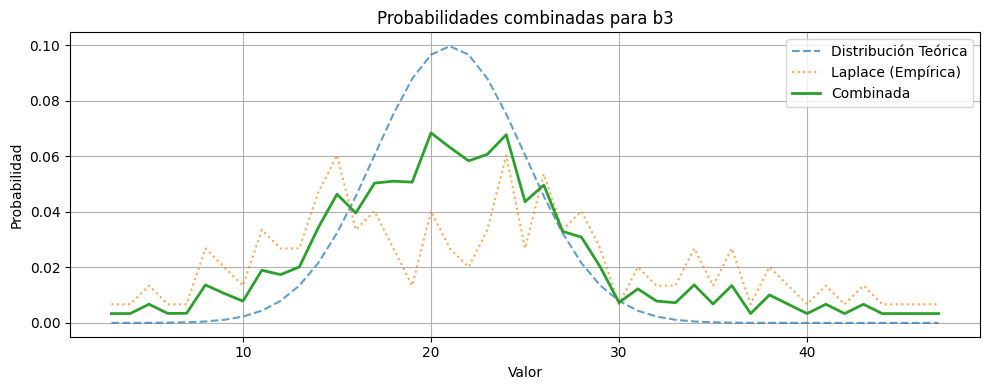

🎯 Siguientes valores más probables para b3:
  20: 0.0685
  24: 0.0678
  21: 0.0633
  23: 0.0608
  22: 0.0584
  18: 0.0511
  19: 0.0507
  17: 0.0504
  26: 0.0497
  15: 0.0464


In [63]:
b3_vals = next_gen_analyze("b3", body_size=104)

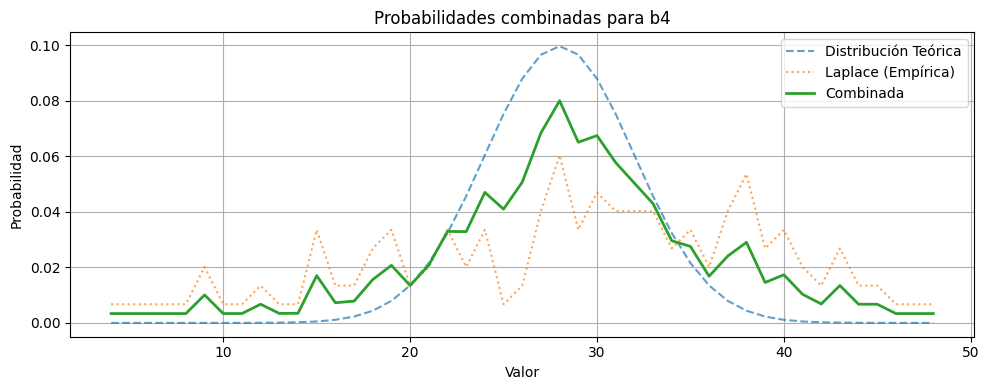

🎯 Siguientes valores más probables para b4:
  28: 0.0801
  27: 0.0685
  30: 0.0675
  29: 0.0651
  31: 0.0578
  26: 0.0507
  32: 0.0504
  24: 0.0470
  33: 0.0430
  25: 0.0410


In [64]:
b4_vals = next_gen_analyze("b4", body_size=104)

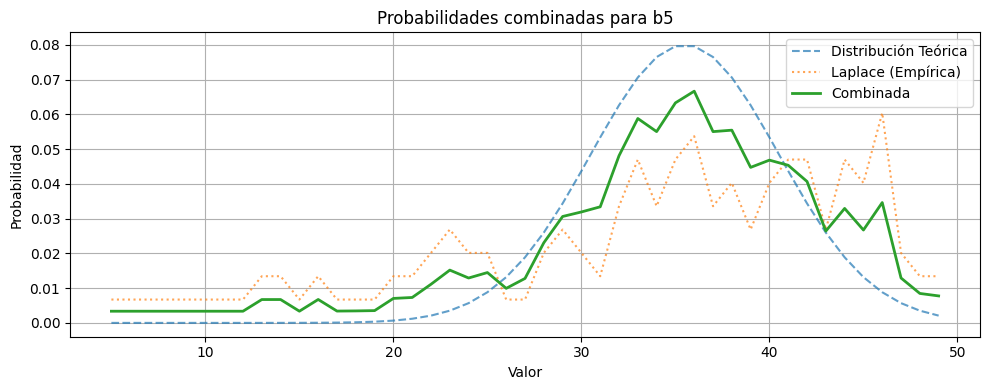

🎯 Siguientes valores más probables para b5:
  36: 0.0666
  35: 0.0633
  33: 0.0588
  38: 0.0554
  34: 0.0550
  37: 0.0550
  32: 0.0481
  40: 0.0468
  41: 0.0453
  39: 0.0447


In [65]:
b5_vals = next_gen_analyze("b5", body_size=104)

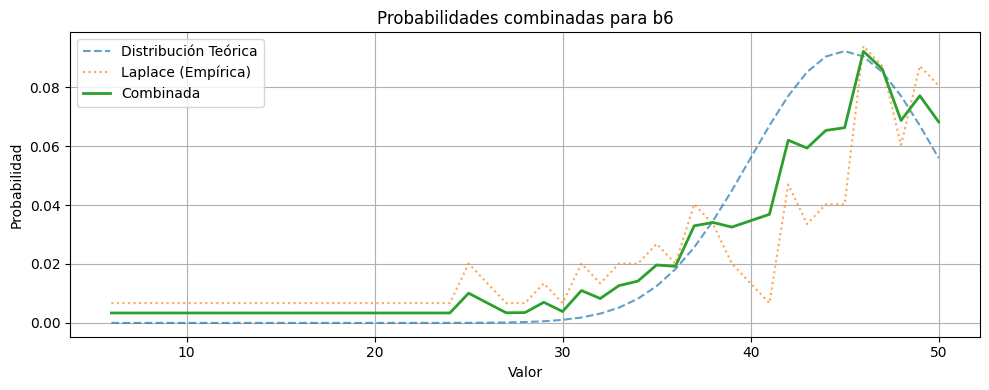

🎯 Siguientes valores más probables para b6:
  46: 0.0922
  47: 0.0862
  49: 0.0771
  48: 0.0687
  50: 0.0683
  45: 0.0663
  44: 0.0654
  42: 0.0620
  43: 0.0594
  41: 0.0369


In [66]:
b6_vals = next_gen_analyze("b6", body_size=104)